In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-04-08 14:12:43.138519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775657563.524614      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775657563.632789      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775657564.562856      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775657564.562915      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775657564.562919      55 computation_placer.cc:177] computation placer alr

In [3]:
max_features = 10000  

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
maxlen = 200  

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

In [5]:
model = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=128, input_length=maxlen),

    layers.LSTM(64, return_sequences=False),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-08 14:13:25.845785: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 165ms/step - accuracy: 0.7094 - loss: 0.5418 - val_accuracy: 0.8600 - val_loss: 0.3360
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.9031 - loss: 0.2611 - val_accuracy: 0.8410 - val_loss: 0.3518
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - accuracy: 0.9386 - loss: 0.1796 - val_accuracy: 0.8580 - val_loss: 0.4659
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 159ms/step - accuracy: 0.9537 - loss: 0.1352 - val_accuracy: 0.8642 - val_loss: 0.4185
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - accuracy: 0.9698 - loss: 0.0880 - val_accuracy: 0.8486 - val_loss: 0.4535


In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8461 - loss: 0.4684
Test Accuracy: 0.8470399975776672


In [9]:
embedding_dims = [64, 128]
lstm_units_list = [32, 64, 128]
dropouts = [0.3, 0.5]

results = []


In [10]:
for emb_dim in embedding_dims:
    for lstm_units in lstm_units_list:
        for dropout_rate in dropouts:

            print("\nTesting config:")
            print(f"Embedding: {emb_dim}, LSTM: {lstm_units}, Dropout: {dropout_rate}")


            model = keras.Sequential([
                layers.Embedding(input_dim=max_features, output_dim=emb_dim, input_length=maxlen),

                layers.LSTM(lstm_units),

                layers.Dense(64, activation='relu'),
                layers.Dropout(dropout_rate),

                layers.Dense(1, activation='sigmoid')
            ])

            model.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                x_train, y_train,
                epochs=3,
                batch_size=64,
                validation_split=0.2,
                verbose=1
            )

            test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

            print(f"Test Accuracy: {test_acc:.4f}")


            results.append({
                "embedding_dim": emb_dim,
                "lstm_units": lstm_units,
                "dropout": dropout_rate,
                "test_accuracy": test_acc
            })



Testing config:
Embedding: 64, LSTM: 32, Dropout: 0.3
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.6706 - loss: 0.5687 - val_accuracy: 0.8192 - val_loss: 0.4067
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.9030 - loss: 0.2565 - val_accuracy: 0.8758 - val_loss: 0.3022
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.9417 - loss: 0.1609 - val_accuracy: 0.8664 - val_loss: 0.3235
Test Accuracy: 0.8644

Testing config:
Embedding: 64, LSTM: 32, Dropout: 0.5
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.6850 - loss: 0.5636 - val_accuracy: 0.8538 - val_loss: 0.3370
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9128 - loss: 0.2348 - val_accuracy: 0.8824 - val_loss: 0.2982
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.9425 - loss: 0.1633 - val_accuracy: 0.8720 - val_loss: 0.3590
Test Accuracy: 0.8634

Testing config:
Embedding: 64, LSTM: 64, Dropout: 0.3
Epoch 1/3
313/313

In [11]:
best_model = max(results, key=lambda x: x['test_accuracy'])

print("\n BEST CONFIGURATION:")
print(best_model)


 BEST CONFIGURATION:
{'embedding_dim': 128, 'lstm_units': 32, 'dropout': 0.5, 'test_accuracy': 0.8691200017929077}


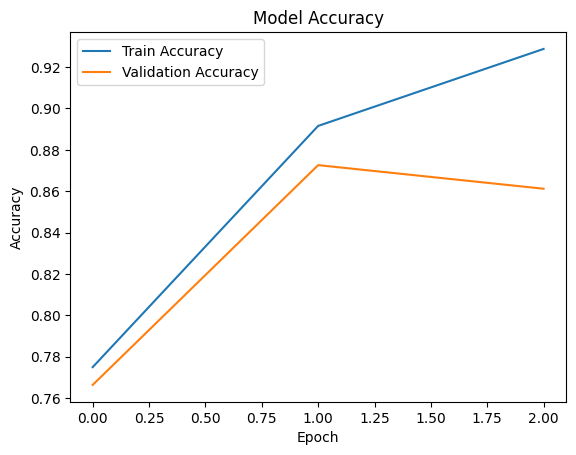

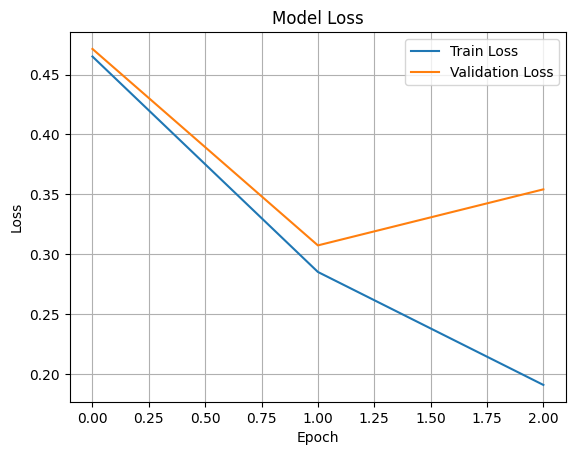

In [12]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()



plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.grid()
plt.show()